In [1]:
!git clone -b to_eval https://github.com/Jun-tsune/CS282_Final_Project.git

Cloning into 'CS282_Final_Project'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (370/370), done.
remote: Compressing objects: 100% (217/217), done.
remote: Total 370 (delta 194), reused 295 (delta 122), pack-reused 0 (from 0)
Receiving objects: 100% (370/370), 1.02 MiB | 1.11 MiB/s, done.
Resolving deltas: 100% (194/194), done.


In [2]:
%cd CS282_Final_Project
!pip install munch tqdm omegaconf wandb pyyaml

/content/CS282_Final_Project


In [3]:
import sys, os

project_path = "/content/CS282_Final_Project"
sys.path.append(project_path)
sys.path.append(os.path.join(project_path, "src"))

In [4]:
!touch /content/CS282_Final_Project/src/__init__.py

In [5]:
# if don't use wandb online
#!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src&& WANDB_MODE=offline python -m src.train model_yaml=config_model_1 train_yaml=config_train_1 out_dir=outputs_baseline test_run=False training.num_tasks=1

In [5]:
!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src && python -m src.train model_yaml=config_model_experiment4 train_yaml=config_train_experiment4 out_dir=outputs_baseline test_run=False

Running with: {'out_dir': 'outputs_baseline/id_e6f73e81-b761-4ec5-9b30-88aed35235d4', 'model_yaml': 'src/config/config_model/config_model_experiment4.yaml', 'train_yaml': 'src/config/config_train/config_train_experiment4.yaml', 'test_run': False, 'wandb': {'project': 'in-context-training', 'entity': 'UC_Berkeley_CS282', 'notes': None, 'log_every_steps': 100, 'name': None}, 'training': {'num_tasks': None, 'num_training_examples': None, 'task': 'linear_regression', 'data': 'gaussian', 'task_kwargs': {}, 'batch_size': 64, 'learning_rate': 0.0003, 'save_every_steps': 10000, 'keep_every_steps': 100000, 'train_steps': 5000, 'resume_id': None, 'device': 'cuda', 'curriculum': {'dims': {'start': 10, 'end': 10, 'inc': 1, 'interval': 500}, 'points': {'start': 32, 'end': 512, 'inc': 32, 'interval': 500}}}, 'model': {'model_family': 'compressive', 'n_embd': 256, 'n_layer': 2, 'n_head': 8, 'n_dims': 10, 'n_positions': 4096, 'embd_pdrop': 0.1, 'resid_pdrop': 0.0, 'attn_pdrop': 0.0, 'mem_len': 128, 'c

In [15]:
patch_code = """
import sys
import os
import torch

sys.path.append('/content/CS282_Final_Project')

import src.eval_cross_length
import src.eval

# Patch to force batch_size=1 to avoid OOM and handle tuple output
original_eval_model = src.eval.eval_model

def patched_eval_model(model, *args, **kwargs):
    kwargs['batch_size'] = 1

    # Wrapper to handle tuple return from model
    class ModelWrapper:
        def __init__(self, original_model):
            self.original_model = original_model

        def __call__(self, *args, **kwargs):
            out = self.original_model(*args, **kwargs)
            if isinstance(out, tuple):
                return out[0]
            return out

        def __getattr__(self, name):
            return getattr(self.original_model, name)

        def to(self, device):
            self.original_model.to(device)
            return self

    wrapped_model = ModelWrapper(model)
    return original_eval_model(wrapped_model, *args, **kwargs)

src.eval.eval_model = patched_eval_model
if hasattr(src.eval_cross_length, 'eval_model'):
    src.eval_cross_length.eval_model = patched_eval_model

# Set arguments for the script
sys.argv = [
    "eval_cross_length.py",
    "--run_dir", "outputs_baseline/id_e6f73e81-b761-4ec5-9b30-88aed35235d4",
    "--n_points", "2048"
]

if __name__ == "__main__":
    print("Running patched eval with batch_size=1 and model wrapper")
    src.eval_cross_length.main()
"""

with open("run_patched.py", "w") as f:
    f.write(patch_code)

!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src && \
 export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True && \
 python run_patched.py

Running patched eval with batch_size=1 and model wrapper
Running cross-length eval 'standard' with n_points=2048, batch_size=8, num_eval_examples=256
Running cross-length eval 'random_quadrants' with n_points=2048, batch_size=8, num_eval_examples=256
^C


In [20]:
patch_code = """
import sys
import os
import torch

sys.path.append('/content/CS282_Final_Project')

import src.eval_cross_length
import src.eval

# Patch to force batch_size=1 to avoid OOM and handle tuple output
original_eval_model = src.eval.eval_model

def patched_eval_model(model, *args, **kwargs):
    kwargs['batch_size'] = 1

    # Wrapper to handle tuple return from model
    class ModelWrapper:
        def __init__(self, original_model):
            self.original_model = original_model

        def __call__(self, *args, **kwargs):
            out = self.original_model(*args, **kwargs)
            if isinstance(out, tuple):
                return out[0]
            return out

        def __getattr__(self, name):
            return getattr(self.original_model, name)

        def to(self, device):
            self.original_model.to(device)
            return self

    wrapped_model = ModelWrapper(model)
    return original_eval_model(wrapped_model, *args, **kwargs)

src.eval.eval_model = patched_eval_model
if hasattr(src.eval_cross_length, 'eval_model'):
    src.eval_cross_length.eval_model = patched_eval_model

# Set arguments for the script
sys.argv = [
    "eval_cross_length.py",
    "--run_dir", "outputs_baseline/id_e6f73e81-b761-4ec5-9b30-88aed35235d4",
    "--n_points", "4096"
]

if __name__ == "__main__":
    print("Running patched eval with batch_size=1 and model wrapper")
    src.eval_cross_length.main()
"""

with open("run_patched.py", "w") as f:
    f.write(patch_code)

!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src && \
 export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True && \
 python run_patched.py

Running patched eval with batch_size=1 and model wrapper
Running cross-length eval 'standard' with n_points=4096, batch_size=8, num_eval_examples=256
Traceback (most recent call last):
  File "/content/CS282_Final_Project/run_patched.py", line 51, in <module>
    src.eval_cross_length.main()
  File "/content/CS282_Final_Project/src/eval_cross_length.py", line 68, in main
    metrics = eval_model(model=model, **local_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/CS282_Final_Project/run_patched.py", line 36, in patched_eval_model
    return original_eval_model(wrapped_model, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/CS282_Final_Project/src/eval.py", line 186, in eval_model
    metrics = eval_batch(model, task_sampler, xs, xs_p)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/CS282_Final_Project/src/eval.py", line 49, in eval_batch
    metrics = task.get_metric()(pred.cpu(), ys

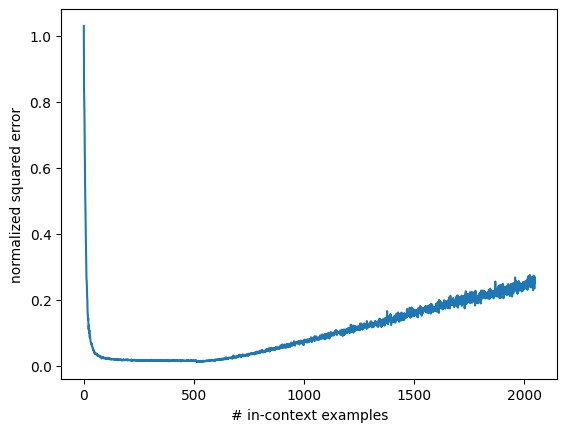

In [18]:
import json, numpy as np, matplotlib.pyplot as plt

with open(
    "/content/metrics_crosslen_2048.json"
) as f:
    m = json.load(f)

curve = np.array(m["mean"])
k = np.arange(len(curve))
d = 10

plt.plot(k, curve / d)
plt.xlabel("# in-context examples")
plt.ylabel("normalized squared error")
plt.show()

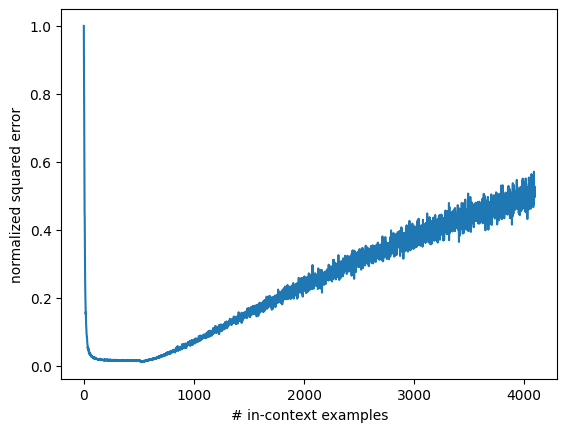

In [19]:
import json, numpy as np, matplotlib.pyplot as plt

with open(
    "/content/metrics_crosslen_4096.json"
) as f:
    m = json.load(f)

curve = np.array(m["mean"])
k = np.arange(len(curve))
d = 10

plt.plot(k, curve / d)
plt.xlabel("# in-context examples")
plt.ylabel("normalized squared error")
plt.show()